Raw shape: (1096, 8)
name              0
price_usd         0
category          0
rating          902
review_count    755
image_url       147
product_url       0
source            0
dtype: int64
category
Pokemon Merchandise    755
Computers - Laptops    117
Other                   99
Kitchen Accessories     30
Groceries               27
Computers - Tablets     21
Sports Accessories      17
Smartphones             16
Mobile Accessories      14
Name: count, dtype: int64
Clean shape: (1096, 11)
count     1096.000000
mean       479.799781
std       2383.842232
min          0.790000
25%         74.930000
50%        146.050000
75%        224.790000
max      36999.990000
Name: price_usd, dtype: float64


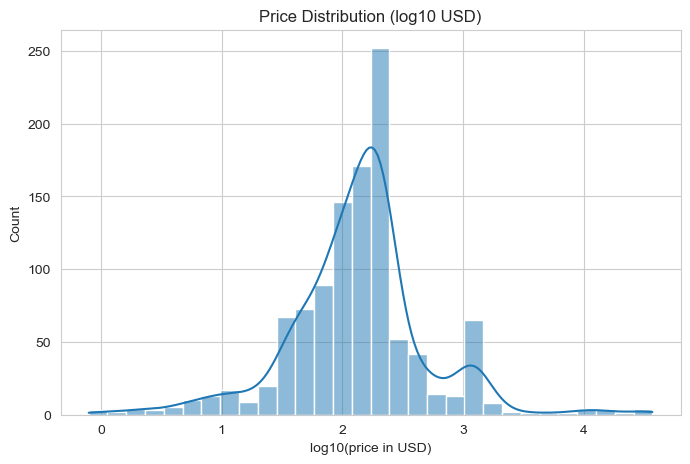

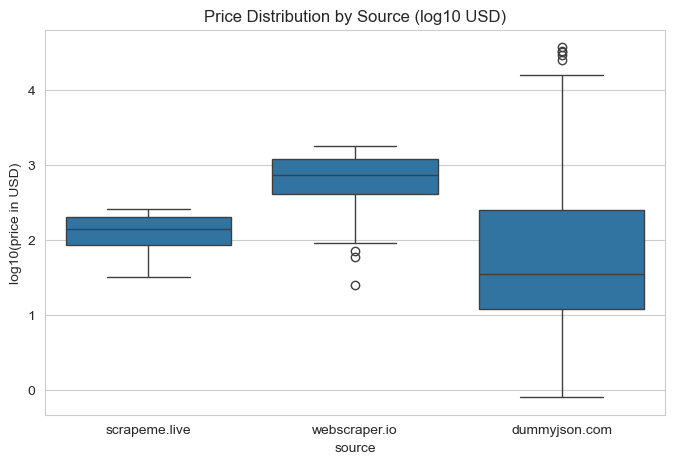

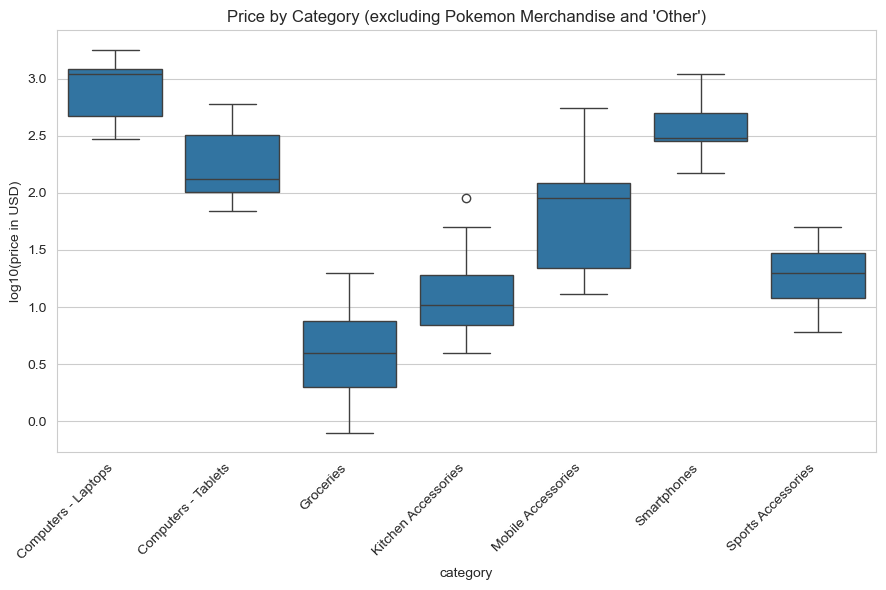

['Computers - Laptops', 'Computers - Tablets', 'Groceries', 'Kitchen Accessories', 'Mobile Accessories', 'Smartphones', 'Sports Accessories']
Rows with a real rating: 194 -- source breakdown:
source
dummyjson.com    194
Name: count, dtype: int64


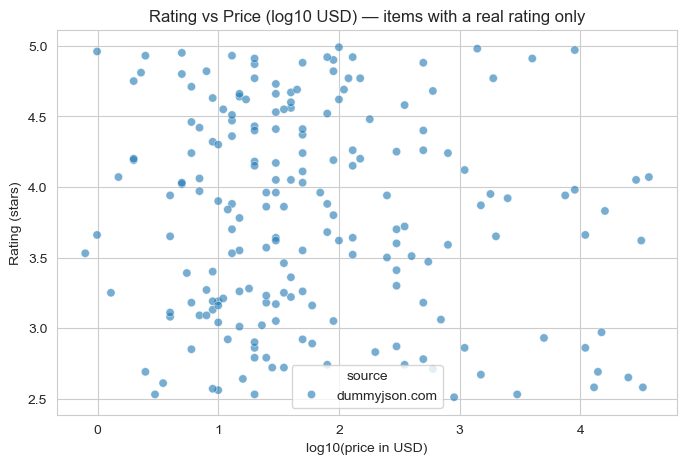

              precision    recall  f1-score   support

           0       0.62      0.70      0.65        23
           1       0.46      0.38      0.41        16

    accuracy                           0.56        39
   macro avg       0.54      0.54      0.53        39
weighted avg       0.55      0.56      0.55        39

ROC AUC: 0.5665760869565217
Confusion matrix:
 [[16  7]
 [10  6]]


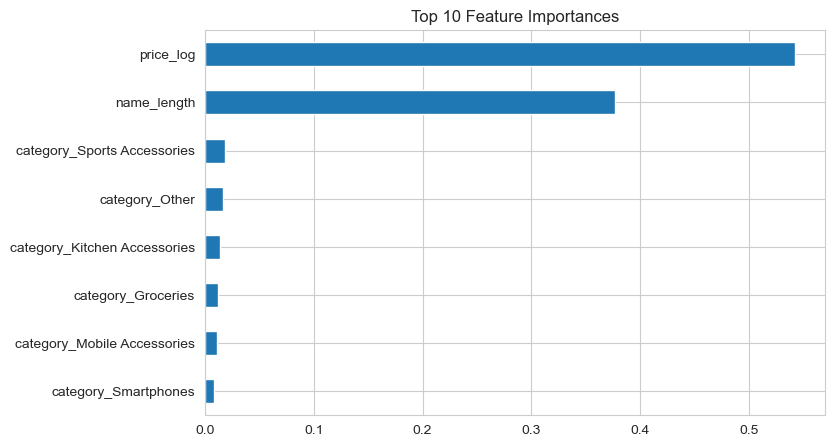

C:\Users\Laxmi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


         price_log  name_length
segment                        
0.0       2.167245     7.635211
1.0       2.609295    29.934066
2.0       1.349114    10.674641
3.0       3.169882    17.511628
segment  source       
0.0      scrapeme.live    663
         webscraper.io     30
         dummyjson.com     17
1.0      webscraper.io     56
         dummyjson.com     35
2.0      dummyjson.com    114
         scrapeme.live     92
         webscraper.io      3
3.0      webscraper.io     58
         dummyjson.com     28
Name: count, dtype: int64


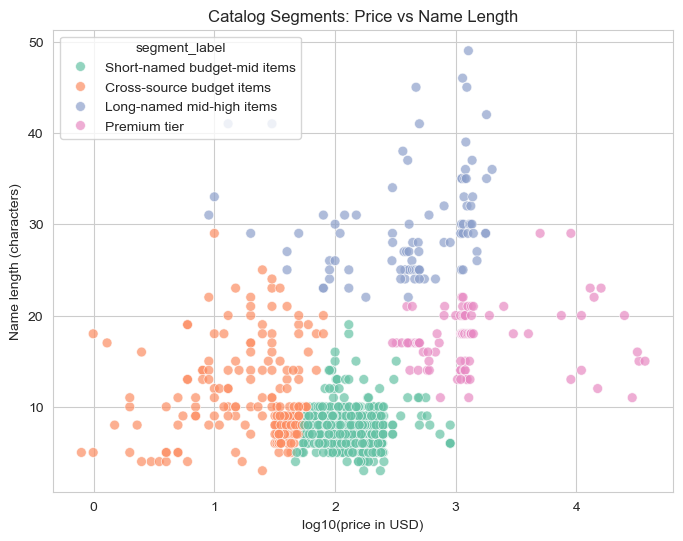

Final saved shape: (1096, 13)


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("ecommerce_raw.csv")
print("Raw shape:", df.shape)
print(df.isnull().sum())

# Collapse rare categories (fewer than 10 items) into "Other"
counts = df["category"].value_counts()
rare = counts[counts < 10].index
df["category"] = df["category"].apply(lambda c: "Other" if c in rare else c)
print(df["category"].value_counts())


# %% [STEP 2] Feature engineering
df["name_length"] = df["name"].str.len()
df["price_band"] = pd.cut(
    df["price_usd"], bins=[0, 20, 60, 150, 100000],
    labels=["budget", "mid", "premium", "luxury"]
)
# Log-transform price: the combined catalog spans $0.79 to $36,999.99 across
# three very different product domains (collectibles, electronics, vehicles),
# so raw price is not comparable across the full dataset. price_log is used
# for any chart/model spanning multiple sources or categories.
df["price_log"] = np.log10(df["price_usd"])

df.to_csv("ecommerce_clean.csv", index=False)
print("Clean shape:", df.shape)
print(df["price_usd"].describe())
df.head()


# %% [STEP 3] EDA — price distribution (log scale)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df["price_log"], bins=30, kde=True)
plt.title("Price Distribution (log10 USD)")
plt.xlabel("log10(price in USD)")
plt.savefig("chart_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [STEP 3] EDA — price by source
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="source", y="price_log")
plt.title("Price Distribution by Source (log10 USD)")
plt.ylabel("log10(price in USD)")
plt.savefig("chart_price_by_source.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [STEP 3] EDA — price by category (excluding Pokemon Merchandise and 'Other')
chart_data = df[(df["source"] != "scrapeme.live") & (df["category"] != "Other")]

plt.figure(figsize=(9, 6))
sns.boxplot(data=chart_data, x="category", y="price_log")
plt.title("Price by Category (excluding Pokemon Merchandise and 'Other')")
plt.xticks(rotation=45, ha="right")
plt.ylabel("log10(price in USD)")
plt.tight_layout()
plt.savefig("chart_price_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
print(sorted(chart_data["category"].unique()))


# %% [STEP 3] EDA — rating vs price (only rows with a real rating)
rated = df.dropna(subset=["rating"])
print("Rows with a real rating:", len(rated), "-- source breakdown:")
print(rated["source"].value_counts())

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rated, x="price_log", y="rating", hue="source", alpha=0.6)
plt.title("Rating vs Price (log10 USD) — items with a real rating only")
plt.xlabel("log10(price in USD)")
plt.ylabel("Rating (stars)")
plt.savefig("chart_rating_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [STEP 4] Modeling — classify high-rated (4-5 stars) vs not

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rated_only = df.dropna(subset=["rating"]).copy()
rated_only["high_rated"] = (rated_only["rating"] >= 4).astype(int)

features = pd.get_dummies(rated_only[["price_log", "name_length", "category"]], columns=["category"])
target = rated_only["high_rated"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("Confusion matrix:\n", confusion_matrix(y_test, preds))


# %% [STEP 4] Feature importance plot
importances = (
    pd.Series(clf.feature_importances_, index=features.columns)
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.savefig("chart_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [STEP 4] Clustering — segment the full catalog (price + name length)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = df[["price_log", "name_length"]].dropna()
X_scaled = StandardScaler().fit_transform(cluster_features)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[cluster_features.index, "segment"] = km.fit_predict(X_scaled)

print(df.groupby("segment")[["price_log", "name_length"]].mean())
print(df.groupby("segment")["source"].value_counts())

# Label segments based on the price/name-length pattern found during EDA
segment_labels = {
    0: "Short-named budget-mid items",
    1: "Long-named mid-high items",
    2: "Cross-source budget items",
    3: "Premium tier",
}
df["segment_label"] = df["segment"].map(segment_labels)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="price_log", y="name_length", hue="segment_label", palette="Set2", s=50, alpha=0.7)
plt.title("Catalog Segments: Price vs Name Length")
plt.xlabel("log10(price in USD)")
plt.ylabel("Name length (characters)")
plt.savefig("chart_segments.png", dpi=150, bbox_inches="tight")
plt.show()

df.to_csv("ecommerce_clean.csv", index=False)
print("Final saved shape:", df.shape)